<a href="https://colab.research.google.com/github/askaasky/ml_1/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. IMPORT LIBRARY DAN LOADING DATA

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

data = pd.read_csv('diagnosed_cbc_data_v4.csv')

2. DATA UNDERSTANDING

In [13]:
print("===== 5 BARIS DATA AWAL =====")
print (data.head(5))

print("===== INFO DATA =====")
print(data.info())

print("===== DESKRIPSI DATA =====")
print(data.describe())

print("===== CEK MISSING VALUE =====")
print(data.isnull().sum())

print("===== GAMBARAN UMUM DATASET =====")
print("Jumlah data:", data.shape)
print("\nJumlah tiap kelas:")
print(data['Diagnosis'].value_counts())

===== 5 BARIS DATA AWAL =====
    WBC  LYMp  NEUTp  LYMn  NEUTn   RBC  HGB    HCT   MCV   MCH  MCHC    PLT  \
0  10.0  43.2   50.1   4.3    5.0  2.77  7.3   24.2  87.7  26.3  30.1  189.0   
1  10.0  42.4   52.3   4.2    5.3  2.84  7.3   25.0  88.2  25.7  20.2  180.0   
2   7.2  30.7   60.7   2.2    4.4  3.97  9.0   30.5  77.0  22.6  29.5  148.0   
3   6.0  30.2   63.5   1.8    3.8  4.22  3.8   32.8  77.9  23.2  29.8  143.0   
4   4.2  39.1   53.7   1.6    2.3  3.93  0.4  316.0  80.6  23.9  29.7  236.0   

    PDW   PCT                      Diagnosis  
0  12.5  0.17  Normocytic hypochromic anemia  
1  12.5  0.16  Normocytic hypochromic anemia  
2  14.3  0.14         Iron deficiency anemia  
3  11.3  0.12         Iron deficiency anemia  
4  12.8  0.22  Normocytic hypochromic anemia  
===== INFO DATA =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1281 entries, 0 to 1280
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  ----- 

3. DATA PROCESSING

In [15]:
# Load data baru
data = pd.read_csv('diagnosed_cbc_data_v4.csv')

# Salin data sebelum cleaning
data_before = data.copy()

# Cleaning
data_clean = data[(data['HGB'] > 0) &
                  (data['MCV'] > 0) &
                  (data['MCH'] > 0) &
                  (data['HCT'] > 0) &
                  (data['NEUTp'] >= 0) & (data['NEUTp'] <= 100) &
                  (data['LYMp'] >= 0) & (data['LYMp'] <= 100)]

print("Jumlah data sebelum:", len(data_before))
print("Jumlah data sesudah:", len(data_clean))

Jumlah data sebelum: 1281
Jumlah data sesudah: 1277


In [16]:
# Outlier removal
data_before_outlier = data_clean.copy()

cols_outlier = ['HGB', 'MCV', 'MCH', 'PLT']
mask = np.ones(len(data_clean), dtype=bool)
for col in cols_outlier:
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    mask &= (data_clean[col] >= lower) & (data_clean[col] <= upper)

data_outlier = data_clean[mask]

print("Jumlah data sebelum:", len(data_before_outlier))
print("Jumlah data sesudah:", len(data_outlier))

Jumlah data sebelum: 1277
Jumlah data sesudah: 1170


4. EDA

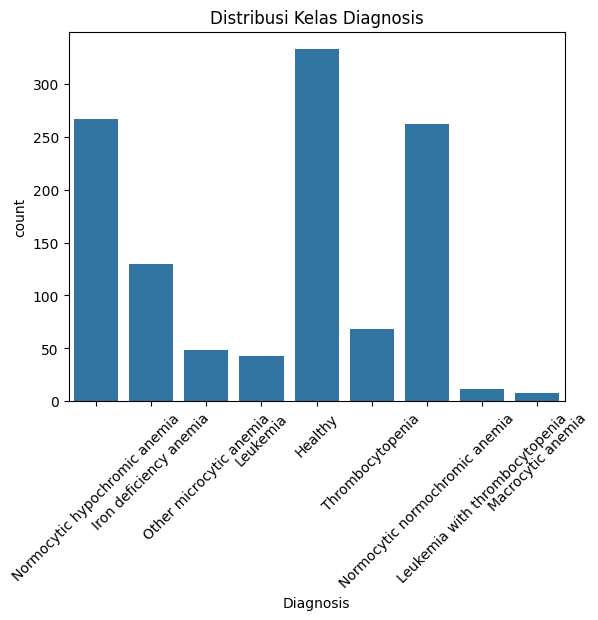

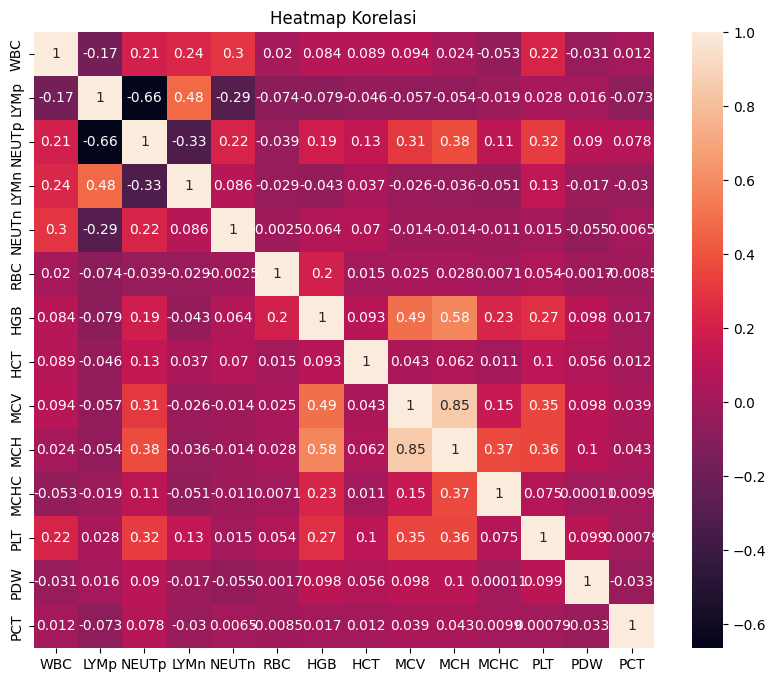

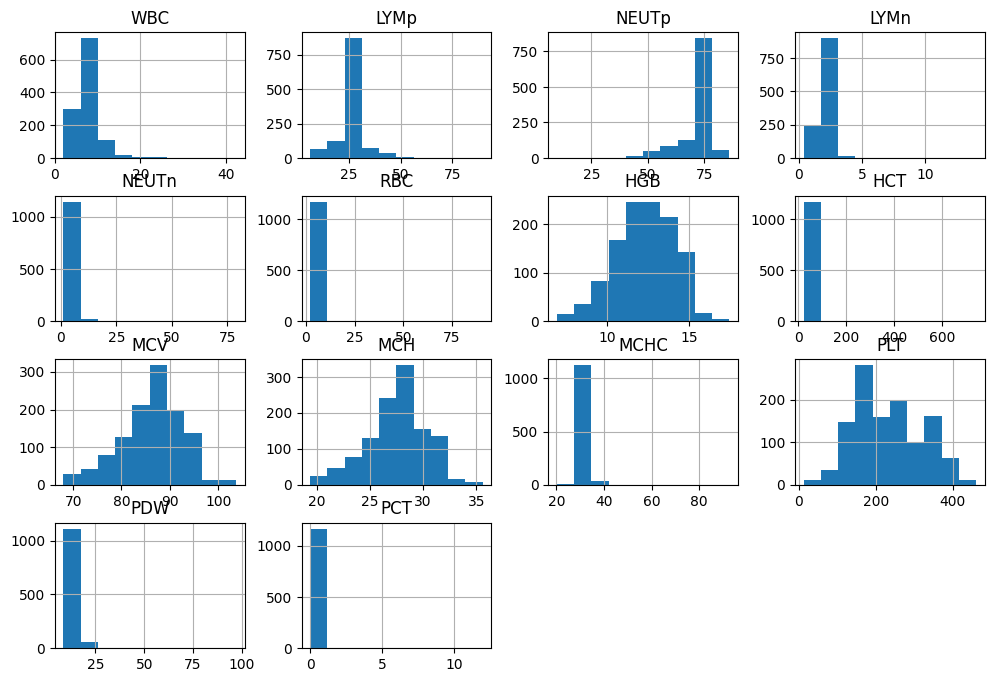

In [39]:
data_final = data_outlier

# Distribusi Kelas Diagnosis
plt.figure()
sns.countplot(x='Diagnosis', data=data_final)
plt.xticks(rotation=45)
plt.title("Distribusi Kelas Diagnosis")
plt.show()


# Heatmap Korelasi (Numeric features, exclude target)
plt.figure(figsize=(10,8))
sns.heatmap(data_final.drop('Diagnosis', axis=1).corr(), annot=True)
plt.title("Heatmap Korelasi")
plt.show()

# Histogram tiap fitur numerik
data_final.select_dtypes(include='float64').hist(figsize=(12,8))
plt.show()

5. DATA FEAUTURE & TARGET SELECTION & ENCODING

In [20]:
# X: fitur, y: target
X = data_final.drop('Diagnosis', axis=1)
y = data_final['Diagnosis']

# Encode target menjadi numeric
le = LabelEncoder()
y = le.fit_transform(y)

6. DATA SPLITING, SCALING DAN EVALUASI MODEL

DATA SPLITING DAN SCALING (70 : 30)

In [21]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scaling fitur numeric
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

EVALUASI MODEL (70 : 30)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

Best Param : {'class_weight': None, 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 10}
Train Acc  : 0.9938949938949939
Test Acc   : 0.9772079772079773


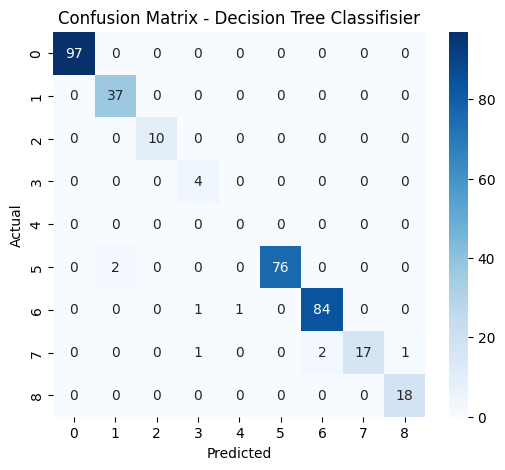

In [26]:
param_dt = {
    'max_depth': [2, 3, 4],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10, 15],
    'class_weight': [None, 'balanced']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    cv=5
)

from IPython.display import display
grid_dt.fit(X_train, y_train)
dt = grid_dt.best_estimator_

display(dt)

print("Best Param :", grid_dt.best_params_)
print("Train Acc  :", dt.score(X_train, y_train))
print("Test Acc   :", dt.score(X_test, y_test))

y_pred = dt.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree Classifisier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

results = []
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

results.append(["70:30", "Decision Tree", acc, prec, rec, f1])

SVC(C=10, kernel='linear')

Best Param : {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}
Train Acc  : 0.9706959706959707
Test Acc   : 0.9173789173789174


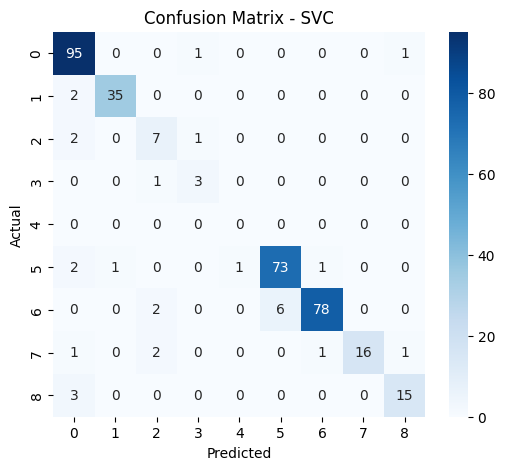

In [27]:
param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

grid_svm = GridSearchCV(
    SVC(),
    param_svm,
    cv=5
)

grid_svm.fit(X_train, y_train)
svm = grid_svm.best_estimator_

display(svm)

print("Best Param :", grid_svm.best_params_)
print("Train Acc  :", svm.score(X_train, y_train))
print("Test Acc   :", svm.score(X_test, y_test))

y_pred = svm.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

results = []
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

results.append(["70:30", "SVM", acc, prec, rec, f1])

LogisticRegression(C=10, max_iter=1000)

Best Param : {'C': 10, 'class_weight': None, 'solver': 'lbfgs'}
Train Acc  : 0.927960927960928
Test Acc   : 0.8888888888888888


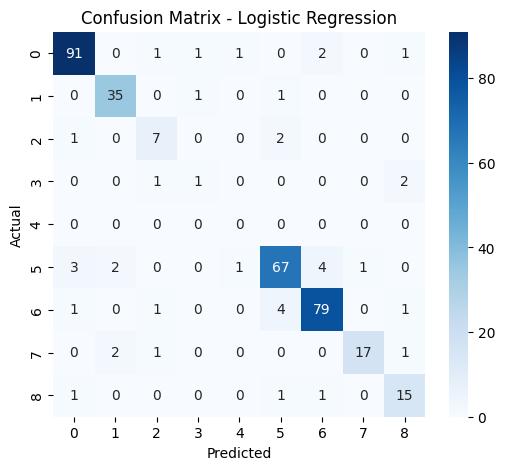

In [28]:
param_lr = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_lr,
    cv=5
)

grid_lr.fit(X_train, y_train)
lr = grid_lr.best_estimator_

display(lr)

print("Best Param :", grid_lr.best_params_)
print("Train Acc  :", lr.score(X_train, y_train))
print("Test Acc   :", lr.score(X_test, y_test))

y_pred = lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

results = []
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

results.append(["70:30", "Logistic Regression", acc, prec, rec, f1])

DATA SPLITING DAN SCALING (80 : 20)

In [29]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling fitur numeric
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

EVALUASI MODEL (80 : 20)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

Best Param : {'class_weight': None, 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 10}
Train Acc  : 0.9903846153846154
Test Acc   : 1.0


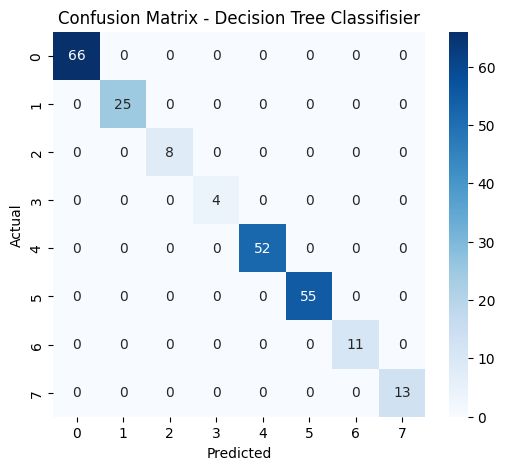

In [30]:
param_dt = {
    'max_depth': [2, 3, 4],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10, 15],
    'class_weight': [None, 'balanced']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    cv=5
)

from IPython.display import display
grid_dt.fit(X_train, y_train)
dt = grid_dt.best_estimator_

display(dt)

print("Best Param :", grid_dt.best_params_)
print("Train Acc  :", dt.score(X_train, y_train))
print("Test Acc   :", dt.score(X_test, y_test))

y_pred = dt.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree Classifisier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

results = []
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

results.append(["80:20", "Decision Tree", acc, prec, rec, f1])

SVC(C=10, kernel='linear')

Best Param : {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}
Train Acc  : 0.9658119658119658
Test Acc   : 0.9444444444444444


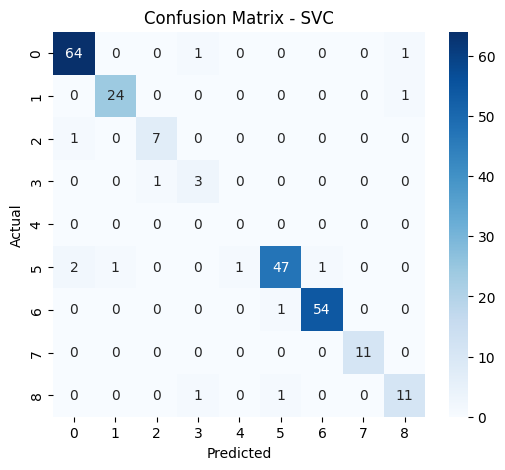

In [31]:
param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

grid_svm = GridSearchCV(
    SVC(),
    param_svm,
    cv=5
)

grid_svm.fit(X_train, y_train)
svm = grid_svm.best_estimator_

display(svm)

print("Best Param :", grid_svm.best_params_)
print("Train Acc  :", svm.score(X_train, y_train))
print("Test Acc   :", svm.score(X_test, y_test))

y_pred = svm.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

results = []
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

results.append(["80:20", "SVM", acc, prec, rec, f1])

LogisticRegression(C=10, max_iter=1000)

Best Param : {'C': 10, 'class_weight': None, 'solver': 'lbfgs'}
Train Acc  : 0.9273504273504274
Test Acc   : 0.8760683760683761


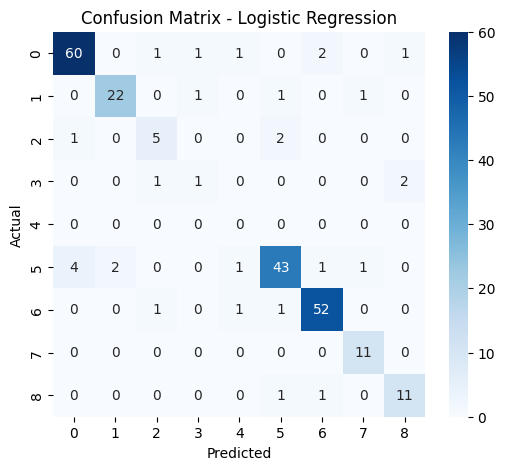

In [32]:
param_lr = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_lr,
    cv=5
)

grid_lr.fit(X_train, y_train)
lr = grid_lr.best_estimator_

display(lr)

print("Best Param :", grid_lr.best_params_)
print("Train Acc  :", lr.score(X_train, y_train))
print("Test Acc   :", lr.score(X_test, y_test))

y_pred = lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

results = []
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

results.append(["80:20", "Logistic Regression", acc, prec, rec, f1])

DATA SPLITING DAN SCALING (90 : 10)

In [33]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

# Scaling fitur numeric
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

EVALUASI MODEL (90 : 10)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

Best Param : {'class_weight': None, 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 10}
Train Acc  : 0.9914529914529915
Test Acc   : 1.0


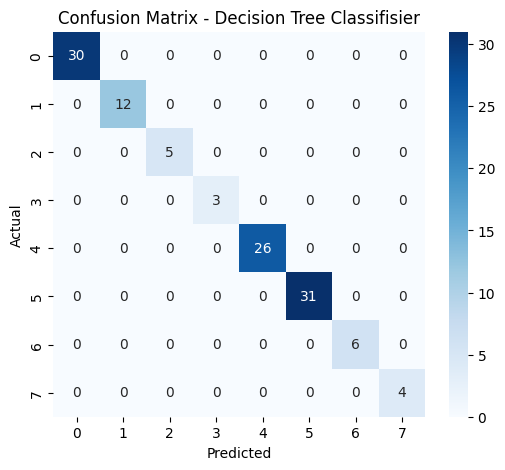

In [34]:
param_dt = {
    'max_depth': [2, 3, 4],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10, 15],
    'class_weight': [None, 'balanced']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    cv=5
)

from IPython.display import display
grid_dt.fit(X_train, y_train)
dt = grid_dt.best_estimator_

display(dt)

print("Best Param :", grid_dt.best_params_)
print("Train Acc  :", dt.score(X_train, y_train))
print("Test Acc   :", dt.score(X_test, y_test))

y_pred = dt.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree Classifisier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

results = []
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

results.append(["90:10", "Decision Tree", acc, prec, rec, f1])

SVC(C=10, kernel='linear')

Best Param : {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}
Train Acc  : 0.9667616334283001
Test Acc   : 0.9572649572649573


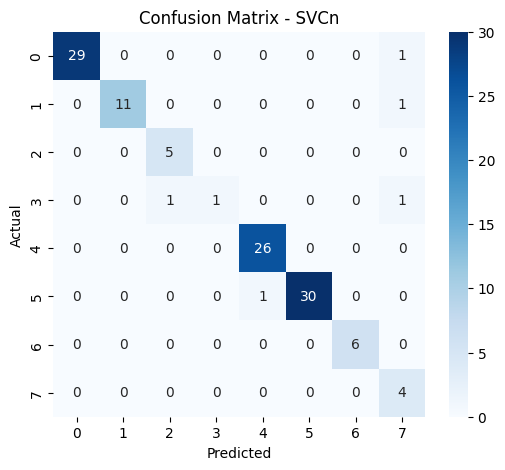

In [35]:
param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

grid_svm = GridSearchCV(
    SVC(),
    param_svm,
    cv=5
)

grid_svm.fit(X_train, y_train)
svm = grid_svm.best_estimator_

display(svm)

print("Best Param :", grid_svm.best_params_)
print("Train Acc  :", svm.score(X_train, y_train))
print("Test Acc   :", svm.score(X_test, y_test))

y_pred = svm.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVCn')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

results.append(["90:10", "SVM", acc, prec, rec, f1])

LogisticRegression(C=10, max_iter=1000)

Best Param : {'C': 10, 'class_weight': None, 'solver': 'lbfgs'}
Train Acc  : 0.9278252611585945
Test Acc   : 0.8888888888888888


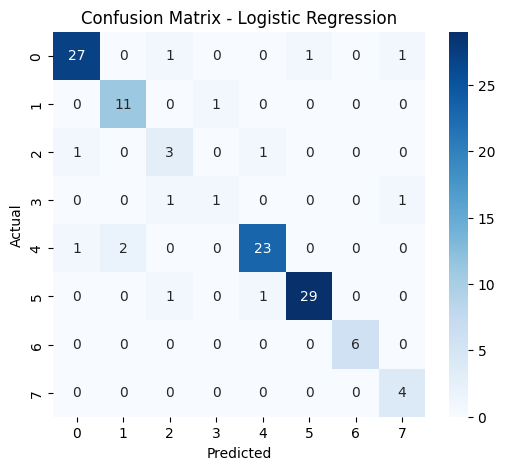

In [36]:
param_lr = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_lr,
    cv=5
)

grid_lr.fit(X_train, y_train)
lr = grid_lr.best_estimator_

display(lr)

print("Best Param :", grid_lr.best_params_)
print("Train Acc  :", lr.score(X_train, y_train))
print("Test Acc   :", lr.score(X_test, y_test))

y_pred = lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

results.append(["90:10", "Logistic Regression", acc, prec, rec, f1])


===== HASIL MODEL =====
   Split                Model  Accuracy  Precision    Recall  F1 Score
0  90:10        Decision Tree  1.000000   1.000000  1.000000  1.000000
1  90:10                  SVM  0.957265   0.969995  0.957265  0.956629
2  90:10  Logistic Regression  0.888889   0.894344  0.888889  0.889498

===== MODEL TERBAIK =====
   Split                Model  Accuracy  Precision    Recall  F1 Score
0  90:10        Decision Tree  1.000000   1.000000  1.000000  1.000000
1  90:10                  SVM  0.957265   0.969995  0.957265  0.956629
2  90:10  Logistic Regression  0.888889   0.894344  0.888889  0.889498


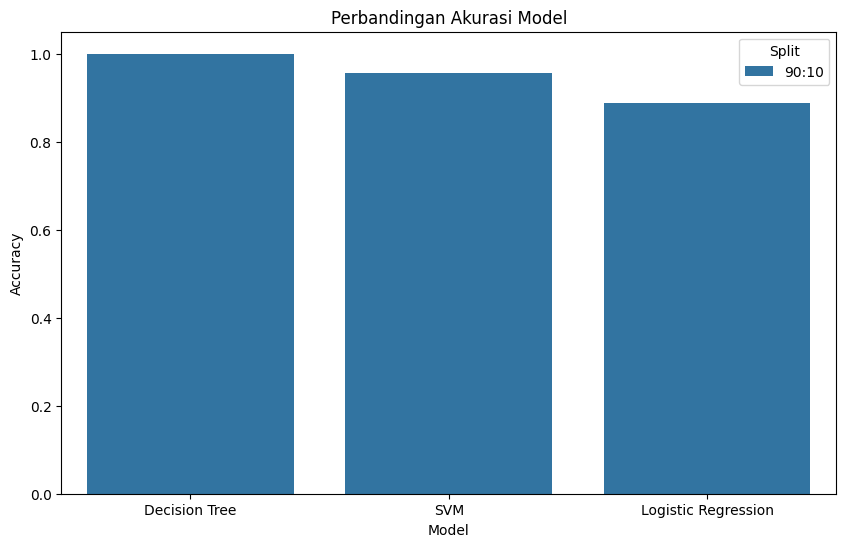

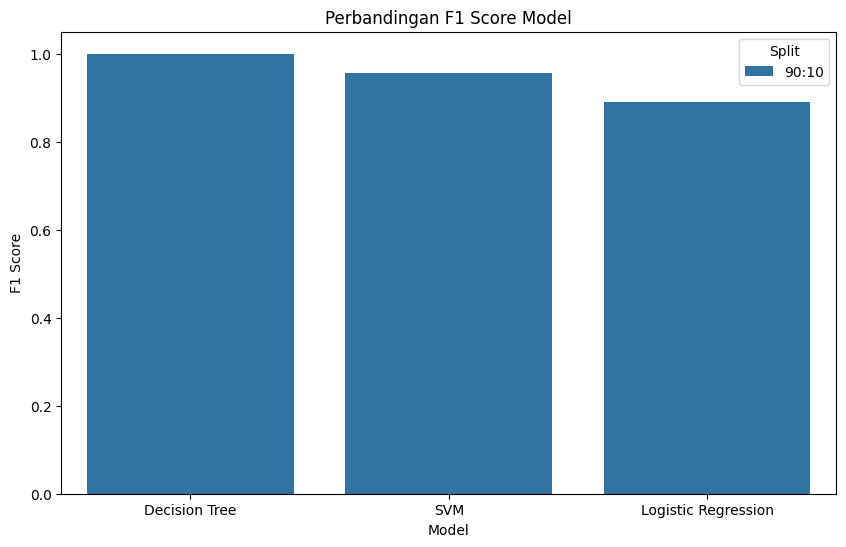

In [38]:
results_df = pd.DataFrame(results, columns=[
    "Split","Model","Accuracy","Precision","Recall","F1 Score"
])

print("\n===== HASIL MODEL =====")
print(results_df)

# Ranking
print("\n===== MODEL TERBAIK =====")
print(results_df.sort_values(by="Accuracy", ascending=False))

# Visualisasi Accuracy
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="Model", y="Accuracy", hue="Split")
plt.title("Perbandingan Akurasi Model")
plt.show()

# Visualisasi F1 Score
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="Model", y="F1 Score", hue="Split")
plt.title("Perbandingan F1 Score Model")
plt.show()